# Life Expectancy (Key)

We perform a multi-linear regression on country life expectancy data.

In [36]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
pd.options.display.max_rows = 20  # Shows 20 rows
pd.options.display.max_columns = None  # Shows All columns

## Loading the dataset

In [38]:
def get_data(source):
    return pd.read_csv(source)


# These lines would load the data locally
# data_root = "./"
# filename = "Life_Expectancy_Data.csv"
# df = get_data(os.path.join(data_root, filename))

# We'll fetch it directly from the web
data_url = "https://aet-cs.github.io/white/ML/lessons/Life_Expectancy_Data.csv"
df = get_data(data_url)
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


`describe` gives a quick overview of each feature

In [39]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


## Data Exploration

Show all the columns. Target is 'Life expectancy'

In [40]:
target = "Life expectancy"
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness 1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='str')

Get the size of the dataframe. Shape returns (rows, cols)

In [41]:
df.shape

(2938, 22)

Let's get all the data types

In [42]:
df.dtypes

Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
                                    ...   
Population                         float64
thinness 1-19 years                float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
Length: 22, dtype: object

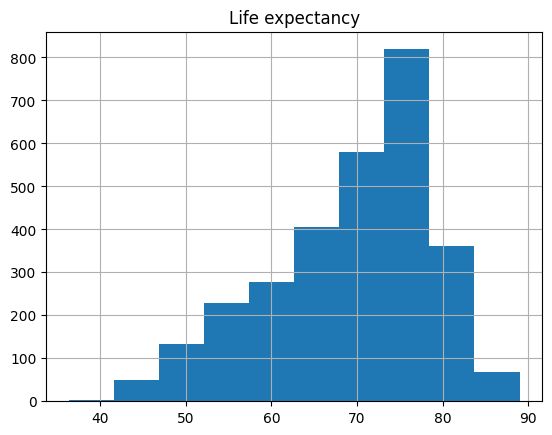

In [43]:
df.hist(target);

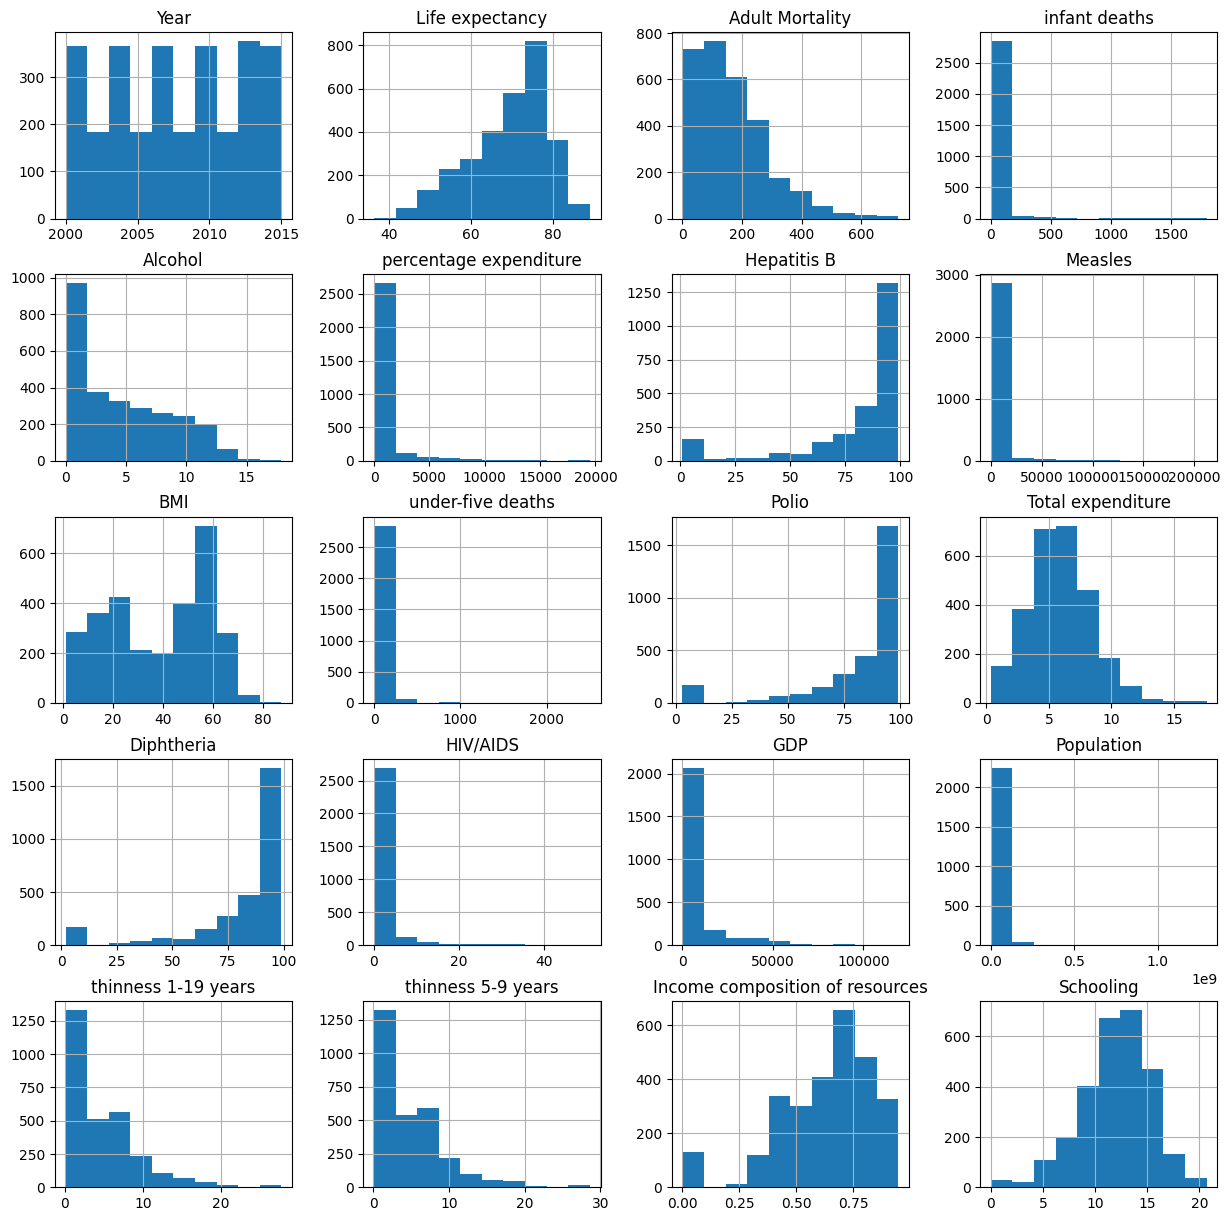

In [44]:
df.hist(figsize=(15,15));

In [45]:
df[df.BMI>60]

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
80,Argentina,2015,Developing,76.3,116.0,8,NaN,0.000000,94.0,0,62.8,9,93.0,NaN,94.0,0.1,13467.12360,43417765.0,1.0,0.9,0.826,17.3
81,Argentina,2014,Developing,76.2,118.0,8,7.93,847.371746,94.0,1,62.2,9,92.0,4.79,94.0,0.1,12245.25645,42981515.0,1.0,0.9,0.825,17.3
82,Argentina,2013,Developing,76.0,119.0,8,8.28,1001.796332,94.0,0,61.6,10,99.0,4.99,94.0,0.1,12976.63642,42539925.0,1.0,0.9,0.823,17.3
83,Argentina,2012,Developing,75.9,12.0,9,8.35,1133.558003,91.0,2,61.0,10,99.0,5.20,91.0,0.1,12969.77120,4296739.0,1.0,0.9,0.822,17.2
112,Australia,2015,Developed,82.8,59.0,1,NaN,0.000000,93.0,74,66.6,1,93.0,NaN,93.0,0.1,56554.38760,23789338.0,0.6,0.6,0.937,20.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2814,Uruguay,2011,Developing,77.0,111.0,0,5.97,417.911744,95.0,0,61.8,1,95.0,8.55,95.0,0.1,14166.49980,3385624.0,1.5,1.5,0.780,15.5
2815,Uruguay,2010,Developing,76.3,118.0,0,6.21,2331.532804,95.0,0,61.2,1,95.0,8.63,95.0,0.1,11938.21200,3374415.0,1.5,1.5,0.777,15.6
2858,Venezuela (Bolivarian Republic of),2015,Developing,74.1,157.0,9,NaN,0.000000,87.0,0,62.1,10,87.0,NaN,87.0,0.1,NaN,NaN,1.6,1.5,0.769,14.3
2859,Venezuela (Bolivarian Republic of),2014,Developing,73.9,158.0,9,6.47,0.000000,78.0,0,61.5,10,79.0,5.26,78.0,0.1,NaN,NaN,1.6,1.5,0.771,14.2


### Correlation matrix heat map

Let's get a quick visual representation of the relationship between features in this dataset. First drop the categorical attributes. Use a **new name** so we don't pollute the original dataframe

In [46]:
df_heat = df.drop(["Country", "Status"], axis = 1)

In [47]:
corr_matrix = df_heat.corr()

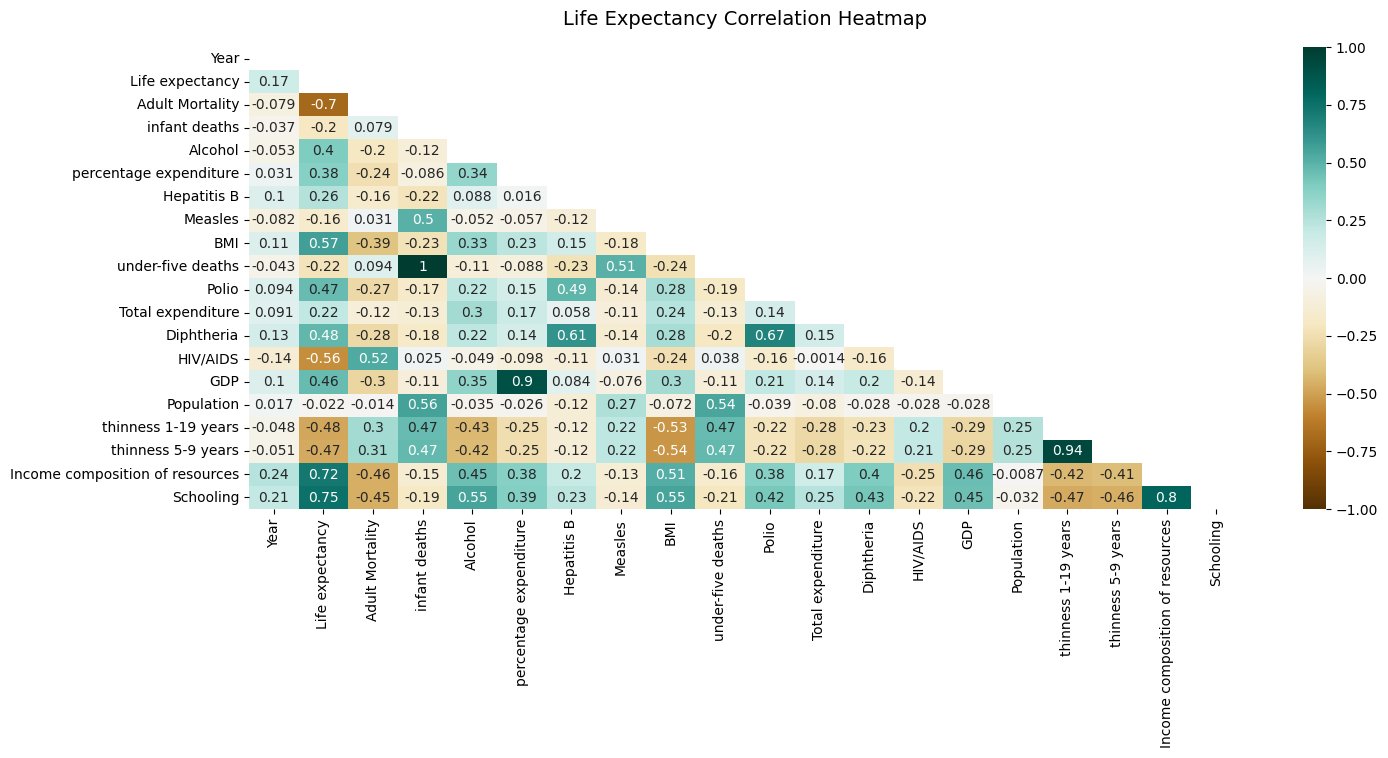

In [48]:
def plot_corr_heatmap(corr_matrix):
    plt.figure(figsize=(16, 6))
    # define the mask to set the values in the upper triangle to True
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    heatmap = sns.heatmap(
        corr_matrix, mask=mask, vmin=-1, vmax=1, annot=True, cmap="BrBG"
    )
    heatmap.set_title(
        "Life Expectancy Correlation Heatmap", fontdict={"fontsize": 14}, pad=16
    )
    plt.show()


plot_corr_heatmap(corr_matrix)

Which features seem to be important?

In [49]:
row_filter = abs(corr_matrix[target]) > 0.1
top_features = pd.DataFrame(corr_matrix[target][row_filter].drop(target))
top_features.sort_values(by=target)

,Life expectancy
Adult Mortality,-0.696359
HIV/AIDS,-0.556556
thinness 1-19 years,-0.477183
thinness 5-9 years,-0.471584
under-five deaths,-0.222529
infant deaths,-0.196557
Measles,-0.157586
Year,0.170033
Total expenditure,0.218086
Hepatitis B,0.256762


## Data Modeling

Here we will run a linear regression. First we need to clean up the data a bit. We will create a data pipeline so we can repeat this process as needed.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

### Linear Regression

The data is split before any preprocessing is fit. A scikit-learn pipeline will learn imputations and category encodings from the training features, then apply the same transformations to the test features.

In [51]:
def make_preprocessor(X, one_hot_encode=False, drop_cols=None, normalize=False):
    if drop_cols is not None:
        X = X.drop(columns=drop_cols)

    numeric_cols = X.select_dtypes(include=np.number).columns
    categorical_cols = X.select_dtypes(exclude=np.number).columns

    if one_hot_encode:
        # "if_binary" avoids a redundant dummy column for two-level features like Status
        category_encoder = OneHotEncoder(
            handle_unknown="ignore", sparse_output=False, drop="if_binary"
        )
    else:
        category_encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        )

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if normalize:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", category_encoder),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_cols),
            ("categorical", categorical_pipeline, categorical_cols),
        ]
    )

In [52]:
def get_test_train(df, test_size=0.2, random_state=42):
    df = df.dropna(subset=[target])
    X = df.drop(columns=target)
    y = df[target]
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

In [53]:
df = get_data(data_url)
X_train, X_test, y_train, y_test = get_test_train(df)

one_hot_encode = False
preprocessor = make_preprocessor(X_train, one_hot_encode=one_hot_encode)
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [54]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Train R-squared = {r2_score(y_train, model.predict(X_train)):.3f}")
print(f"Test R-squared  = {r2_score(y_test, y_pred):.3f}")

Train R-squared = 0.821
Test R-squared  = 0.821


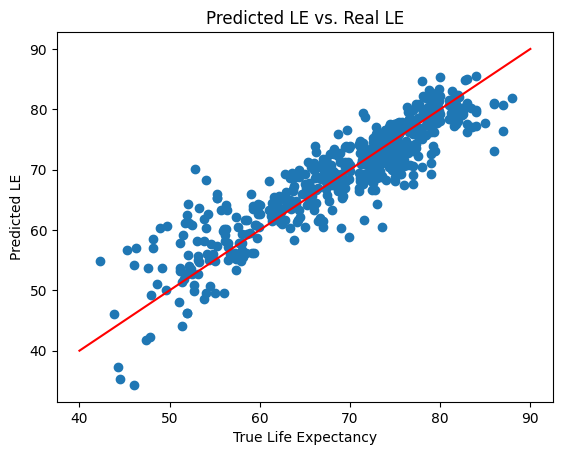

In [55]:
def plot_predictions(y_test, y_pred):
    plt.scatter(y_test, y_pred)
    plt.plot([40, 90], [40, 90], color="red")
    plt.title("Predicted LE vs. Real LE")
    plt.xlabel("True Life Expectancy")
    plt.ylabel("Predicted LE")


plot_predictions(y_test, y_pred)

## Advanced Techniques

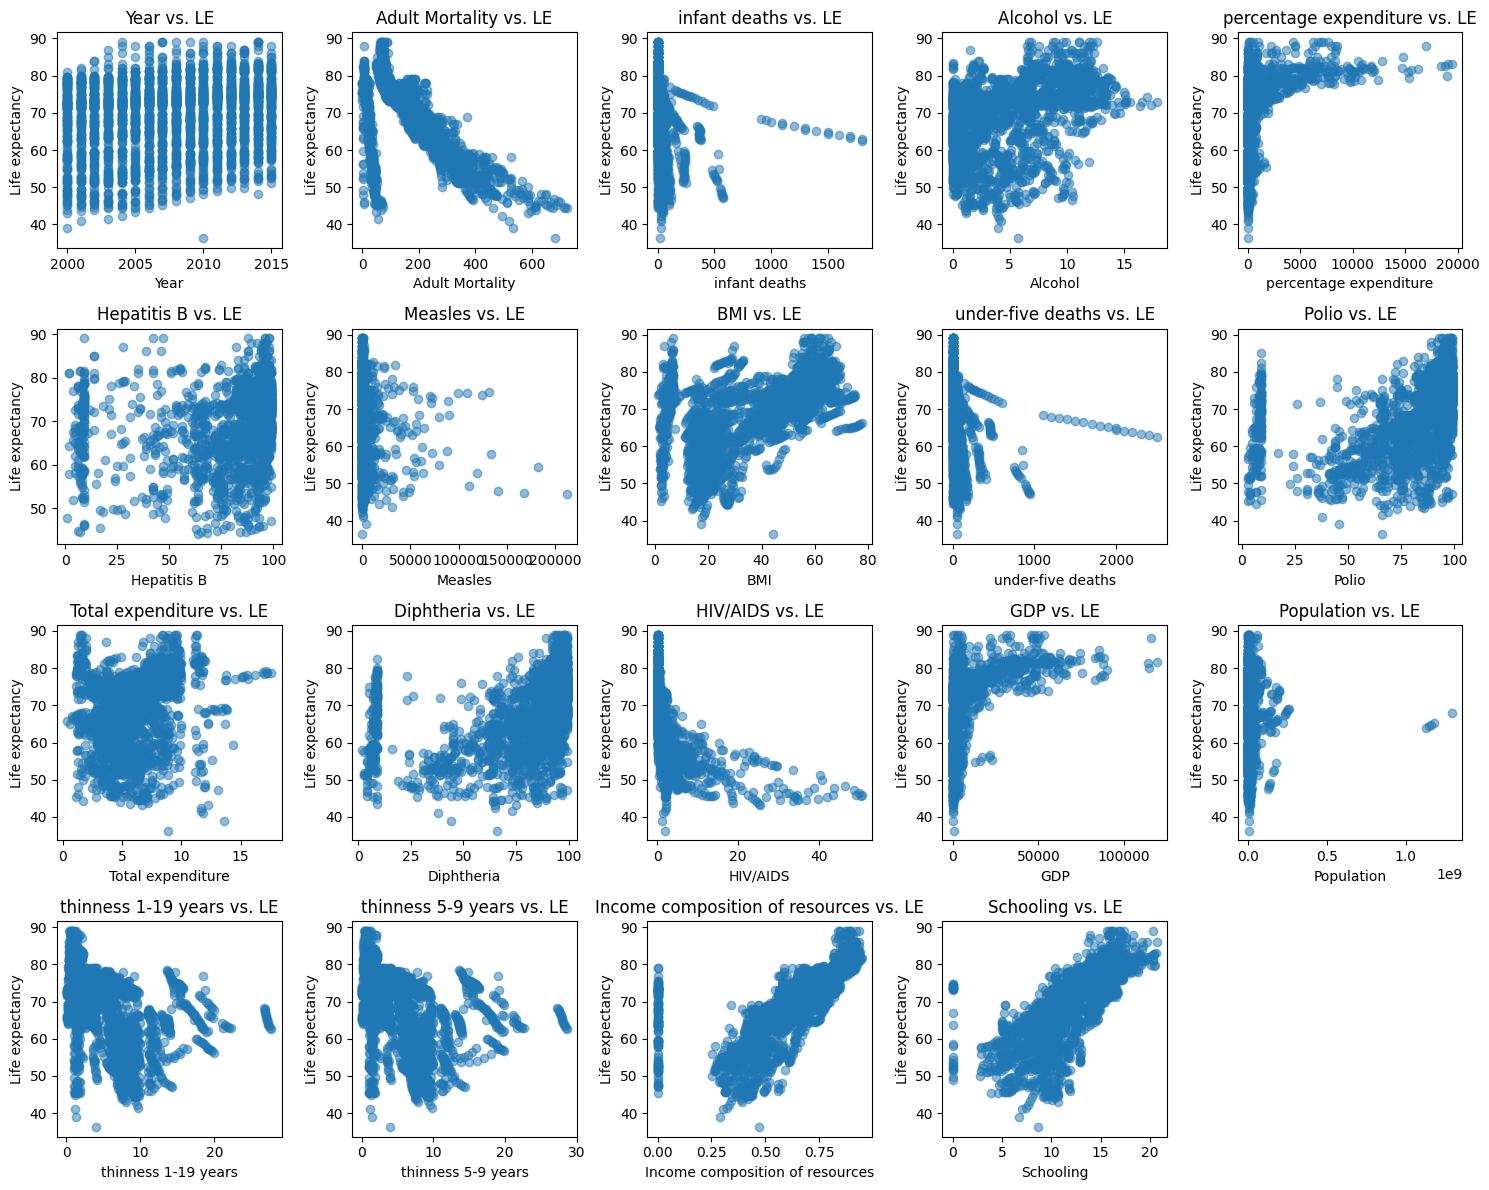

In [56]:
# Scatter plot of every numeric feature against the target
features = df.select_dtypes(include="number").columns.drop(target)

# Set up a grid of subplots
num_features = len(features)
num_cols = 5  # Adjust this to your preference
num_rows = (num_features + num_cols - 1) // num_cols  # Calculates rows needed

plt.figure(figsize=(15, num_rows * 3))

for i, feature in enumerate(features, 1):
    plt.subplot(num_rows, num_cols, i)
    plt.scatter(df[feature], df[target], alpha=0.5)
    plt.title(f"{feature} vs. LE")
    plt.xlabel(feature)
    plt.ylabel(target)

plt.tight_layout()
plt.show()

## Importance Analysis

In [57]:
import statsmodels.api as sm


def fit_ols(X_train, y_train, **preprocessor_kwargs):
    preprocessor = make_preprocessor(X_train, **preprocessor_kwargs)
    X_processed = pd.DataFrame(
        preprocessor.fit_transform(X_train),
        columns=preprocessor.get_feature_names_out(),
        index=X_train.index,
    )
    return sm.OLS(y_train, sm.add_constant(X_processed, has_constant="add")).fit()


ols_model = fit_ols(X_train, y_train, one_hot_encode=one_hot_encode)
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     505.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        12:11:01   Log-Likelihood:                -6601.7
No. Observations:                2342   AIC:                         1.325e+04
Df Residuals:                    2320   BIC:                         1.337e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [58]:
summary_table = ols_model.summary2().tables[1]
sorted_summary = summary_table.sort_values(by="P>|t|")

with pd.option_context("display.max_rows", None):
    display(sorted_summary)

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
numeric__HIV/AIDS,-4.823918e-01,1.930904e-02,-24.982686,3.392115e-122,-5.202566e-01,-4.445270e-01
numeric__Adult Mortality,-2.044663e-02,8.828281e-04,-23.160377,6.265587e-107,-2.217785e-02,-1.871542e-02
numeric__Schooling,6.554411e-01,4.753432e-02,13.788797,1.245910e-41,5.622269e-01,7.486553e-01
numeric__under-five deaths,-7.370018e-02,6.978462e-03,-10.561092,1.693872e-25,-8.738486e-02,-6.001551e-02
numeric__infant deaths,9.977985e-02,9.614355e-03,10.378216,1.071514e-24,8.092622e-02,1.186335e-01
numeric__Diphtheria,4.043544e-02,5.120996e-03,7.896011,4.403380e-15,3.039324e-02,5.047765e-02
numeric__BMI,4.151583e-02,5.583057e-03,7.436038,1.451832e-13,3.056752e-02,5.246413e-02
numeric__Income composition of resources,5.351402e+00,7.239082e-01,7.392376,2.002925e-13,3.931827e+00,6.770977e+00
numeric__Polio,3.021246e-02,4.978154e-03,6.069008,1.498977e-09,2.045036e-02,3.997456e-02
categorical__Status,-1.392425e+00,3.068516e-01,-4.537781,5.974995e-06,-1.994157e+00,-7.906933e-01


# Exercises

1. Notice the multicollinearity warning in the OLS analysis. This can happen when two or more features are linearly related. Find pairs of highly correlated features and drop one from each pair, then rerun the OLS analysis. Can you reduce the warning?

2. The categorical variable `Country` is ordinal-encoded in the baseline, even though that is usually not appropriate for a nominal feature. In the model setup cell, change `one_hot_encode` from `False` to `True` and rerun the subsequent analyses. What effect does this have on test $r^2$?

3. Small models generally generalize better than large models. Experiment with this dataset and find a small subset of features that predicts the outcome as well as the full set, or almost as well. You may preprocess or transform the data however you like.

4. Do your own linear regression! (This is a later project)

## Solution 2

We'll do Exercise 2 first, because what we learn about `Country` here shapes how we approach Exercise 1.

It's easy to one hot encode using the preprocessor defined above. This will create one new 0/1 feature (Column) for every country

In [59]:
ols_model = fit_ols(X_train, y_train, one_hot_encode=True)
ols_model.summary()

/var/folders/_z/fcth_nbd7hg70v8d_k1tt9sr0000gn/T/ipykernel_55280/1657798827.py:11: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  return sm.OLS(y_train, sm.add_constant(X_processed, has_constant="add")).fit()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life expectancy   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     294.2
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        12:11:01   Log-Likelihood:                -4686.1
No. Observations:                2342   AIC:                             9776.
Df Residuals:                    2140   BIC:                         1.094e+04
Df Model:                         201                                         
Covariance Type:            nonrobust                                         
=============================================================================================================================================
                                                                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------
const                                                                      -453.6114     22.600    -20.072      0.000    -497.931    -409.292
numeric__Year                                                                 0.2716      0.012     23.026      0.000       0.248       0.295
numeric__Adult Mortality                                                     -0.0019      0.000     -3.896      0.000      -0.003      -0.001
numeric__infant deaths                                                        0.1027      0.014      7.474      0.000       0.076       0.130
numeric__Alcohol                                                             -0.0313      0.026     -1.227      0.220      -0.081       0.019
numeric__percentage expenditure                                               0.0002   5.48e-05      3.015      0.003    5.78e-05       0.000
numeric__Hepatitis B                                                         -0.0058      0.002     -2.673      0.008      -0.010      -0.002
numeric__Measles                                                          -9.937e-06   4.74e-06     -2.098      0.036   -1.92e-05   -6.47e-07
numeric__BMI                                                                 -0.0041      0.003     -1.269      0.205      -0.011       0.002
numeric__under-five deaths                                                   -0.0735      0.009     -7.797      0.000      -0.092      -0.055
numeric__Polio                                                                0.0052      0.003      2.073      0.038       0.000       0.010
numeric__Total expenditure                                                   -0.0545      0.024     -2.236      0.025      -0.102      -0.007
numeric__Diphtheria                                                           0.0048      0.003      1.802      0.072      -0.000       0.010
numeric__HIV/AIDS                                                            -0.3371      0.017    -19.352      0.000      -0.371      -0.303
numeric__GDP                                                               -1.97e-05   8.45e-06     -2.331      0.020   -3.63e-05   -3.13e-06
numeric__Population                                                       -1.878e-09   1.02e-09     -1.845      0.065   -3.87e-09    1.18e-10
numeric__thinness 1-19 years                                                  0.0104      0.030      0.350      0.727      -0.048       0.069
numeric__thinness 5-9 years                                                   0.0259      0.030      0.869      0.385      -0.033       0.084
numeric__Income composition of resources                                     -0.2508      0.488     -

Look at the table above, almost every single country is strongly predictive of the life expectancy. Due to this, the observed $R^2$ is higher than it was with ordinal encoding of the Country value.

In [60]:
def fit_and_score(df, one_hot_encode=False, drop_cols=None, normalize=False):
    X_train, X_test, y_train, y_test = get_test_train(df)
    preprocessor = make_preprocessor(
        X_train,
        one_hot_encode=one_hot_encode,
        drop_cols=drop_cols,
        normalize=normalize,
    )
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", LinearRegression()),
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Train R-squared = {r2_score(y_train, model.predict(X_train)):.3f}")
    print(f"Test R-squared  = {r2_score(y_test, y_pred):.3f}")

    return model, y_test, y_pred


model, y_test, y_pred = fit_and_score(df, one_hot_encode=True)

Train R-squared = 0.965
Test R-squared  = 0.955


This makes me suspicious, though. How well can we predict $y$ using **just** the Country? `make_preprocessor` (and the `fit_and_score` helper above) can drop columns, which we'll use later anyway.

And let's make a dataframe using **just** country as the predictor

In [61]:
country_only = df[["Country", target]]
model, y_test, y_pred = fit_and_score(country_only, one_hot_encode=True, normalize=True)

Train R-squared = 0.927
Test R-squared  = 0.913


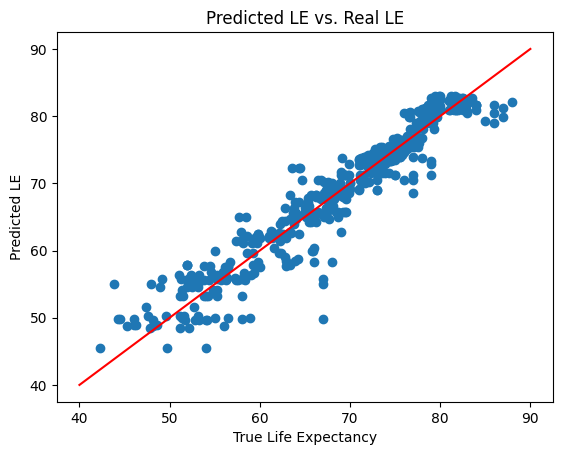

In [62]:
plot_predictions(y_test, y_pred);

That's about as good as using the whole dataset! We should ask, is knowing the 'Country' cheating? If we want to determine what factors affect life expectancy, and we can model the result knowing just the country, then we can't really include 'country' in the model. In the following sections, we drop 'country' and see how strong our predictive model **really** is.

## Solution 1

We'll reuse `fit_and_score` from above to explore this dataset.

Based on the correlation heat-map, I'm choosing to drop `["Country", "infant deaths", "GDP", "thinness 1-19 years", "Schooling"]`. First let's get a Country-free baseline (non-cheating!)

In [63]:
df = get_data(data_url)

model, y_test, y_pred = fit_and_score(
    df, one_hot_encode=True, drop_cols=["Country"], normalize=True
)

Train R-squared = 0.820
Test R-squared  = 0.819


And now drop the selected fields.

In [64]:
drop_cols=["Country", "infant deaths", "GDP", "thinness 1-19 years", "Schooling"]
model, y_test, y_pred = fit_and_score(
    df,
    one_hot_encode=True,
    drop_cols=drop_cols,
    normalize=True,
)

Train R-squared = 0.795
Test R-squared  = 0.787


Let's see how the coefficients look now.

In [65]:
# Show the coefficients for each feature from the trained linear model
preprocessor = model.named_steps["preprocessor"]
regressor = model.named_steps["regressor"]
feature_names = preprocessor.get_feature_names_out()
coef_df = pd.DataFrame(
    {"feature": feature_names, "coefficient": regressor.coef_}
).sort_values("coefficient", ascending=False)


coef_df

,feature,coefficient
14,numeric__Income composition of resources,2.503451
10,numeric__Diphtheria,1.217605
6,numeric__BMI,1.102756
8,numeric__Polio,0.915081
3,numeric__percentage expenditure,0.660174
2,numeric__Alcohol,0.449167
12,numeric__Population,0.186355
9,numeric__Total expenditure,0.143289
0,numeric__Year,0.094580
13,numeric__thinness 5-9 years,-0.271390


And let's inspect the heatmap looking for correlated features.

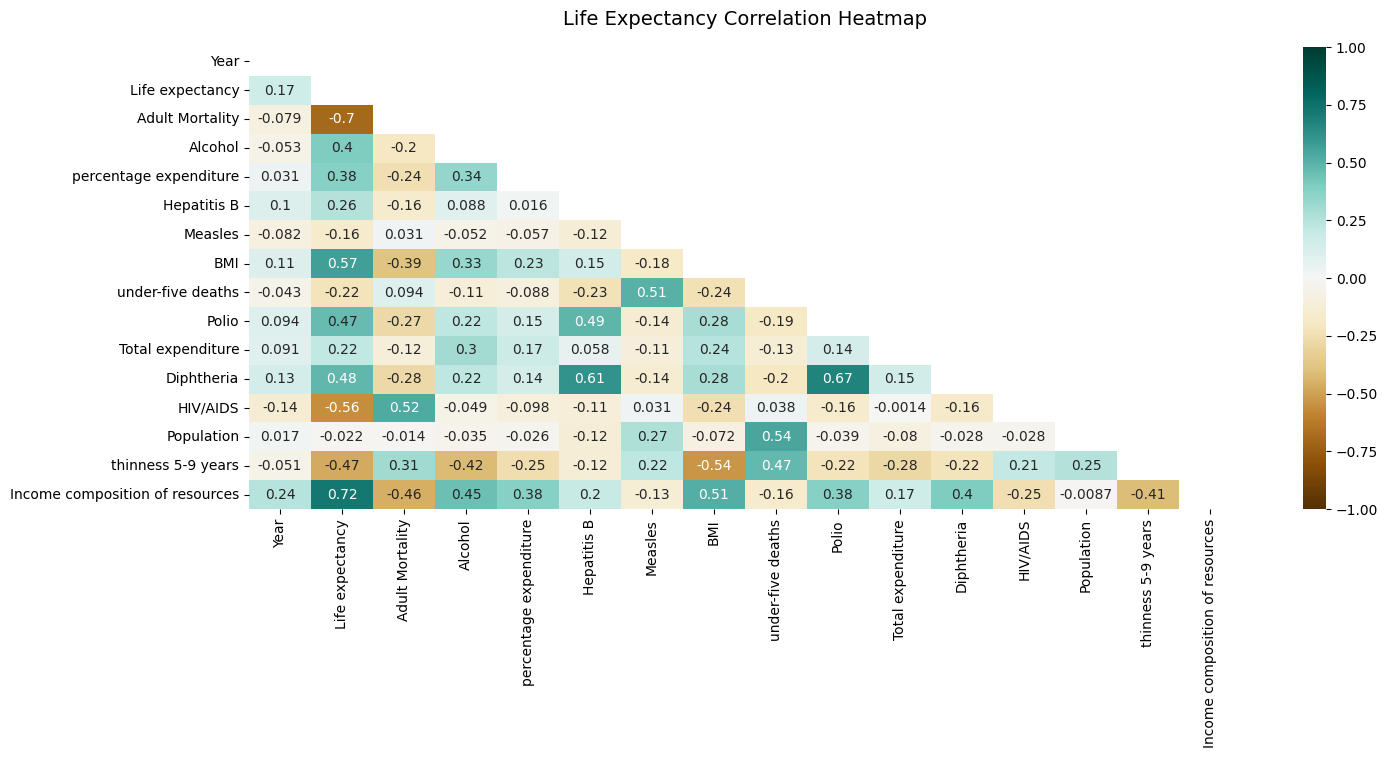

In [66]:
plot_corr_heatmap(df.drop(columns=drop_cols).select_dtypes(include=np.number).corr())

There is another measure we can perform -- the Variance Inflation Factor. It determines the degree to which **each** feature may be a linear combination of all the other features. We'll see more about how to interpret it later, but in general, a VIF more than 3 or so is possibly problematic. The cell below computes it twice: first with every numeric feature, then after dropping `selected_drops`. Both runs use the same rows. VIF can't handle missing values, so unlike the regression pipeline it uses only the complete rows (no imputation).

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def prepare_features(df, drop_cols=()):
    X = (
        df.dropna(subset=[target])
        .drop(columns=target)
        .select_dtypes(include=np.number)
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
    )
    n_before = len(X)
    # Filter rows using every feature so every call uses the same rows.
    X = X.dropna().drop(columns=list(drop_cols))
    print(f"Dropped {n_before - len(X)} rows with missing or non-finite values.")

    constant_cols = X.columns[X.nunique() <= 1]
    if len(constant_cols):
        print("Skipped constant columns:", list(constant_cols))
        X = X.drop(columns=constant_cols)
    if X.shape[1] == 0:
        raise ValueError("No usable numeric feature columns remain.")

    # Center and scale: the VIF regressions have no intercept (in older statsmodels),
    # and the condition number is only meaningful for comparable scales.
    return (X - X.mean()) / X.std(ddof=0)


def report(X, label):
    print(f"{label} condition number of X: {np.linalg.cond(X.to_numpy()):.3g}")
    vif = pd.Series(
        [variance_inflation_factor(X.to_numpy(), i) for i in range(X.shape[1])],
        index=X.columns,
        name="VIF",
    ).sort_values(ascending=False)
    print("Variance inflation factors:")
    print(vif, "\n")


df = get_data(data_url)
selected_drops = ["infant deaths", "GDP", "thinness 1-19 years", "Schooling"]
report(prepare_features(df), "Original")
report(prepare_features(df, selected_drops), "New")

Dropped 1279 rows with missing or non-finite values.
Original condition number of X: 48
Variance inflation factors:
infant deaths                      213.609554
under-five deaths                  203.591034
GDP                                 13.649710
percentage expenditure              12.904426
thinness 1-19 years                  7.606109
thinness 5-9 years                   7.584832
Schooling                            3.538093
Income composition of resources      3.028945
Diphtheria                           2.094307
Alcohol                              2.067310
Population                           1.943421
Adult Mortality                      1.809171
BMI                                  1.802986
Polio                                1.722414
Hepatitis B                          1.680406
Measles                              1.516630
HIV/AIDS                             1.500870
Year                                 1.157920
Total expenditure                    1.124370
Name: VIF,

Now rerun the OLS analysis. Dropping correlated features is not enough to reduce the condition number reported in the OLS notes: it is dominated by features on very different scales (`Population` is around $10^7$ while most others are below $10^3$). Standardizing the features is what removes the warning.

In [68]:
drop_cols = ["Country", *selected_drops]
for normalize in (False, True):
    ols_model = fit_ols(
        X_train, y_train, one_hot_encode=False, drop_cols=drop_cols, normalize=normalize
    )
    print(f"normalize={normalize}: condition number = {ols_model.condition_number:.3g}")

normalize=False: condition number = 2.28e+10
normalize=True: condition number = 9.51


## Solution 3

From the correlation list above, pick a few features that are strongly related to life expectancy but not strongly related to each other (for example, `Schooling` and `Income composition of resources` are highly correlated, so we keep only one). Compare the test $r^2$ with the full Country-free model from Solution 1.

In [69]:
small_features = ["Schooling", "Adult Mortality", "HIV/AIDS", "BMI", "Diphtheria"]
small_drops = df.columns.difference([target, *small_features])
model, y_test, y_pred = fit_and_score(
    df, one_hot_encode=True, drop_cols=list(small_drops), normalize=True
)

Train R-squared = 0.786
Test R-squared  = 0.788
